# Confirmation Bias Project
## Figures from DDMs
After running DDMs using docker on real and simulated data, I used the DockerDDModels_Loader to concatenate all the models parameters in one csv file (allowing me to work with the parameters outside of the docker). Here I will load that csv table to generate the figures.

##### Import important functions and libraries

In [30]:
import os, glob, platform, sys
import numpy as np
import pickle
import seaborn as sns

import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
from scipy import signal
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
#import pingouin as pg
import pandas as pd
from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)
from matplotlib.lines import Line2D
import statsmodels as sms
import matplotlib.colors as mcolors

#import ptitprince as pt
pd.options.display.max_columns = None # display all the columns in pandas dataframe
#import plotly.graph_objects as go
#import plotly.express as px
#from plotly.subplots import make_subplots
#from metadpy.sdt import criterion, dprime, rates, roc_auc, scores

# Functions

In [19]:
colpal1 = ["orange","green"]
colpal1a = ["deeppink","deepskyblue"]
#colpal2 = ['black','green','blue']
colpal1b = ['dodgerblue','navy']
colpal3 = ['green','darkviolet']
colpal2 = ['gold','mediumturquoise','darkblue']

import seaborn as sns
# function that I used to plot multiple data
def barsplot(data, dx, dy, hue, col, row, pal, size, yaxis, axislabels, sizepoint, dodge):    
    sns.set(font_scale = 1.5, style = 'ticks')         
    ort = "v"; pal = pal; sigma = .5
    g = sns.FacetGrid(data ,  row = row, col = col, height= size['height'], aspect=size['aspect'], margin_titles=True) # col="nrep",    
    if sizepoint == None:
        sizepoint = 6
    if yaxis != None:
        g.set(yaxis['ylim'], yaxis['yticks'])   

    g.map_dataframe(sns.stripplot, x = dx, y = dy, palette = pal, hue=hue, size = sizepoint, edgecolor = "white",
                    linewidth = 0.6, jitter = 0.2, orient = ort,alpha = 0.5, dodge=dodge)
    g.map_dataframe(sns.barplot, x = dx, y = dy, palette = pal, hue=hue,  linewidth = 0.6, orient = ort, dodge=dodge)
    
    #g.map_dataframe(sns.violinplot, x = dx, y = dy,  palette = pal,bw = .5, cut = 0.,scale = "area", width = .6, inner = None, orient = ort, linewidth = 0, zorder = 2)
    
    g.add_legend()

    sns.despine(offset = .5,  trim=True);
    # Set x-axis and y-axis labels
    g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15 )
    #g.tight_layout()
    return g

# function that I used to plot multiple data
def barsplot_models(data, dx, dy, hue, col, row, pal, size, yaxis, axislabels, sizepoint, dodge):    
    sns.set(font_scale = 1.5, style = 'ticks')         
    ort = "v"; pal = pal; sigma = .5
    g = sns.FacetGrid(data ,  row = row, col = col, height= size['height'], aspect=size['aspect'], margin_titles=True) # col="nrep",    
    if sizepoint == None:
        sizepoint = 6
    #if yaxis != None:
    #    g.set(yaxis['ylim'], yaxis['yticks'])   
    #g.set(ylim = [0,1] ) 
    g.map_dataframe(sns.barplot, x = dx, y = dy, palette = pal, hue=hue,  linewidth = 0.6, orient = ort, dodge=dodge)
    
    #g.map_dataframe(sns.violinplot, x = dx, y = dy,  palette = pal,bw = .5, cut = 0.,scale = "area", width = .6, inner = None, orient = ort, linewidth = 0, zorder = 2)
    if yaxis is not None:
        for ax in g.axes.flat:
            ax.set_ylim(yaxis) #yaxis['ylim']
            #ax.set_yticks(yaxis['yticks'])


    sns.despine(offset = .5,  trim=True);
    # Set x-axis and y-axis labels
    g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15)
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
    #g.set_xticklabels(rotation=0)
    #g.tight_layout()
    return g

__Setting paths__

In [3]:
# Importing behavioral data from experiment 
if platform.system() == 'Darwin':
    sys_dir = os.path.join('/Users','alex','Library','CloudStorage','OneDrive-UniversitatdeBarcelona') # macv
    results_path = '/Users/alex/OneDrive - Universitat de Barcelona/Projects/Condcision/'
 
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home','freeman','Insync', 'alexisperez@ub.edu', 'OneDrive Biz')  # Linux   
    results_path = '/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet

figures_path = os.path.join(results_path, 'Group_level_analyses','figures') 
# some folders with interesting custom functions
path_utils = os.path.join(sys_dir, 'TOOLBOXES','decoding_toolbox_py','Helper_funcs') 
psychofits = os.path.join(sys_dir, 'TOOLBOXES','psychofit-master')  
sys.path.append(path_utils)
sys.path.append(psychofits)

#import psychofit as psy

# path
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')

In [4]:

module_directory = os.path.abspath(os.path.join(os.getcwd(), '../../Helper_funcs')) # Updated path to helper_funcs

if module_directory not in sys.path:
    sys.path.append(module_directory)
    # print(f"Added {module_directory} to sys.path") # Optional: Add a print for confirmation

# --- Standard Import ---
# Get the module object. This imports it the first time or retrieves it if already loaded.
from use_funcs import *


__Loading simulated dataset and psychometric params__

In [5]:

# Specify the filename from where you want to load the pickle file
csv_file =  results_path + 'Group_level_analyses/sim_data/all_simdata.csv'
# Open the file in binary read mode and load the data from it
all_data = pd.read_csv(csv_file)
# Now 'loaded_data' contains the data that was stored in the pickle file

# Specify the filename from where you want to load the pickle file
csv_file =  results_path + 'Group_level_analyses/sim_data/all_sims.csv'
# Open the file in binary read mode and load the data from it
all_params  = pd.read_csv(csv_file)

__Loading DDMs params__

In [6]:
params_path = os.path.join(hddm_m_path,  'DDMs_params.csv')  
ddms_params = pd.read_csv(params_path)
ddms_params['fitted'] = 'real'
ddms_params.loc[ddms_params['exp_ID'].isin(['threshold_sim', 'lapse_sim', 'Z_sim','slope_sim']), 'fitted'] = 'simul'

 #  Preparing data

In [7]:
# recoding variables
all_data.rename(columns= {'deci' : 'Responses', 'RT' : 'rt', 'stim':'Stimuli'}, inplace=True)
all_data.loc[all_data['Stimuli'] == -1, 'Stimuli'] = 0

all_data['nrep'] = all_data['nrep'].astype('int')
all_data['pre_deci'] = all_data['pre_deci'].astype('int')
all_data['nit'] = all_data['nit'].astype('category')

In [8]:
group_sdt_avg = all_data.groupby(['exp_bias', 'nit','nrep']).apply(sdt)
group_sdt_avg.reset_index(inplace=True)

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3900049082.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sdt_avg = all_data.groupby(['exp_bias', 'nit','nrep']).apply(sdt)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3900049082.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_sdt_avg = all_data.groupby(['exp_bias', 'nit','nrep']).apply(sdt)


In [9]:
modelfit = ddms_params.groupby(['exp_ID', 'model','fitted'], as_index=False)[['aic','bic']].mean()

level_mapping = {
    'nohist' : 'no hist',
    'stimcoding_nohist' : 'no hist',
    'Z' : 'z', 
    'stimcoding_z_prevresp' : 'z',
    'dc': 'dc', 
    'stimcoding_dc_prevresp': 'dc',   
    'stimcoding_zXdc_prevresp' : 'zXdc',
    'stimcoding_dc_prevresp_trial_type' : 'zXdcrepeat'    
}


In [10]:
# Use the replace() method to rename the levels
modelfit['model'] = modelfit['model'].replace(level_mapping)
modelfit['model'] = modelfit['model'].astype('category')
# Reorder categories and assign the result back
modelfit['model'] = modelfit['model'].cat.reorder_categories(['no hist','z','dc','zXdc','zXdcrepeat'])

In [11]:
# Filter data where 'fitted' column is 'sim'
modelsim = modelfit[modelfit['fitted'] == 'simul']

# Remove unused categories from 'model' column (assuming it's categorical)
modelsim['model'] = modelsim['model'].cat.remove_unused_categories()


/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/1100228519.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modelsim['model'] = modelsim['model'].cat.remove_unused_categories()


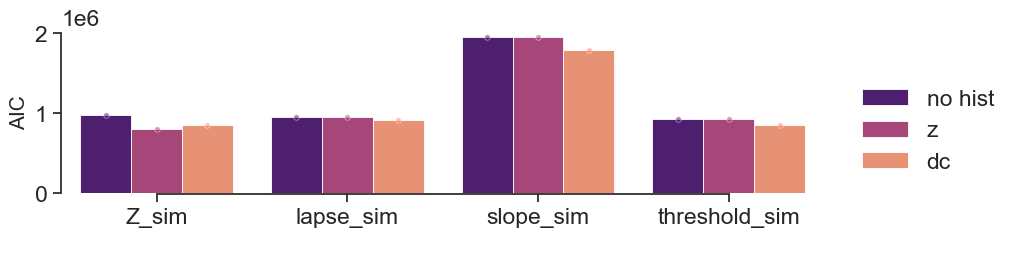

In [20]:

dat = modelsim.copy()
sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] =3
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'AIC'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'exp_ID'; dy = 'bic'; hue = 'model';  row = None; col = None
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot(dat, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = True)

Creating individual IDs for each participant (to prevent modelling taking different subjects with similar names as identical)

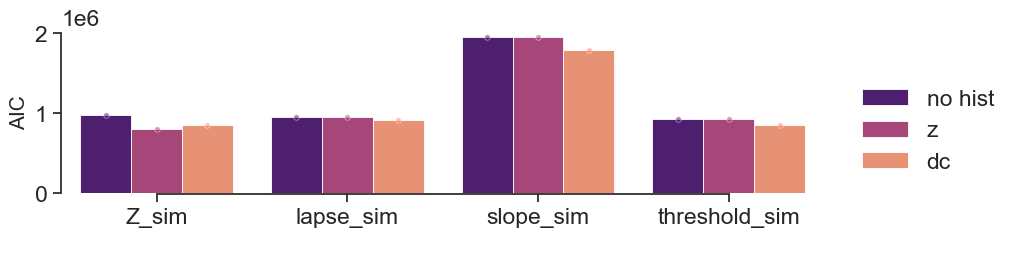

In [21]:
dat = modelsim.copy()
sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] =3
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'AIC'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'exp_ID'; dy = 'bic'; hue = 'model';  row = None; col = None
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot(dat, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = True)

modelsim = ddms_params.groupby(['exp_ID','model'])[['aic','bic']].mean()
modelsim.reset_index(inplace=True)

/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (

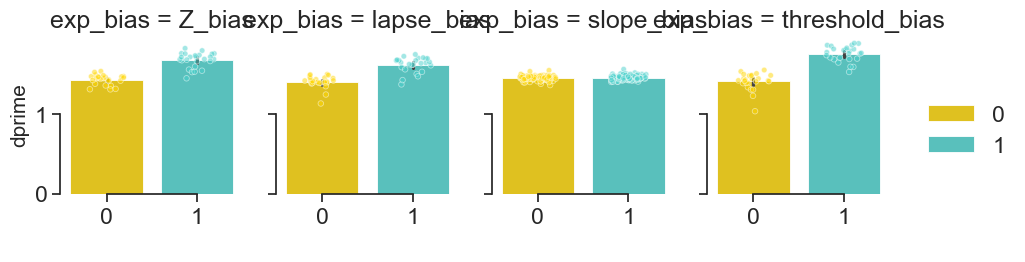

In [22]:

sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'dprime'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'nrep'; dy = 'dprime'; hue = 'nrep';  row = None; col = 'exp_bias'
pal = colpal2

barsplot(group_sdt_avg, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


_Lapse model_

In [23]:
params_stacked 

NameError: name 'params_stacked' is not defined

In [23]:

def sem(x):
    std = np.std(x)
    n = np.size(x)
    sem = std/np.sqrt(n)
    sem = pd.DataFrame({'sem':sem})
    return sem

In [24]:

def sem(x):
    """Calculates the standard error of the mean for a given Series."""
    std = np.std(x)
    n = np.size(x)
    if n > 0:
        sem_value = std / np.sqrt(n)
    else:
        sem_value = np.nan
    return sem_value


In [25]:
# Based on your screenshot, these are likely:
id_vars = ['niter', 'nrep', 'pre_deci', 'model']

# Specify the columns whose values you want to stack
value_vars = ['intercept', 'DV']

params_stacked = pd.melt(
    all_params,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='parameter',     # The new column indicating the original variable name
    value_name='Estimate'  # The new column holding the values (using 'Estimate' as seen in your previous code)
)

grouped_params = params_stacked.groupby([ 'model', 'nrep',  'pre_deci', 'parameter'], as_index=False)[['Estimate']].agg(
    Estimate=('Estimate', 'mean'),  # Calculate the mean and name the output column 'mean_estimate'
    sem=('Estimate', sem)       # Calculate the Standard Error and name the output column 'se_estimate'
    # You could also add 'count', 'std', etc. here if needed
    # count_obs=('Estimate', 'size')
    # std_dev=('Estimate', 'std')
)

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/2200575529.py:58: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/2200575529.py:60: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/2200575529.py:76: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/2200575529.py:78: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",


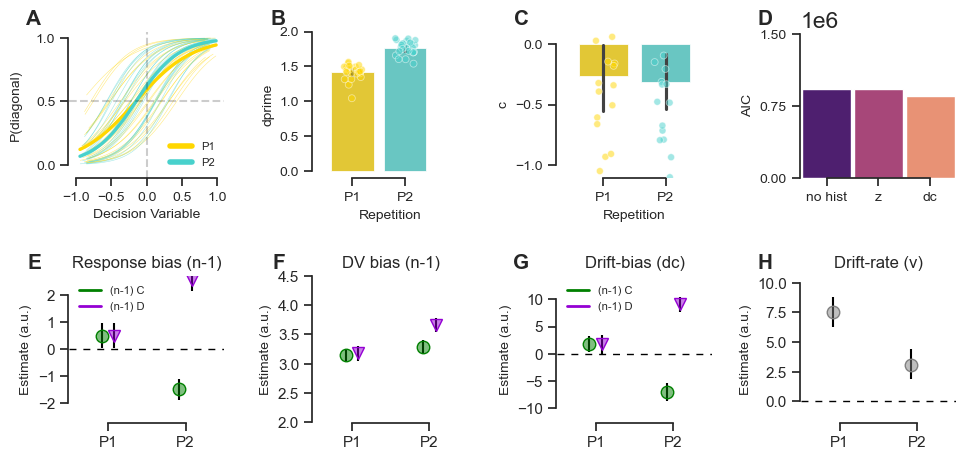

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np
import string

EXP = 'threshold_bias'
EXP_ddm = 'threshold_sim'
best_model = 'dc'
nindividuals = 60
sizepoint = 4
rt = "v"; sigma = .5
dodge = False
mycol = colpal2

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set_palette(colpal2)

# ── Panel [0,0]: Psychometric function ──────────────────────────────────────
axis = (0, 0)
dat = all_data[all_data.exp_bias == EXP]
nrep_labels   = np.unique(dat.nrep)
id_subj_labels = np.unique(dat.nit)

for i in range(0, nindividuals):
    dat2 = dat.loc[dat.nit == i, :]
    for cell in nrep_labels:
        sns.regplot(x="DV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                    ci=True, n_boot=1, ax=axes[axis], truncate=True,
                    line_kws={'alpha': 0.5, 'lw': 0.4}, color=colpal2[cell])

for cell in nrep_labels:
    sns.regplot(x="DV", y="Responses", data=dat.loc[dat.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                ci=True, n_boot=1, ax=axes[axis], label=cell, truncate=True,
                line_kws={'lw': 2.4}, color=colpal2[cell])

axes[axis].axvline(0, ls='--', color='black', alpha=0.2)
axes[axis].axhline(0.5, ls='--', color='black', alpha=0.2)
axes[axis].set_ylabel('P(diagonal)', fontsize=10, labelpad=10)
axes[axis].set_xlabel('Decision Variable', fontsize=10)
axes[axis].set_xlim(-1.1, 1.1);  axes[axis].set_xticks([-1, -0.5, 0, 0.5, 1])
axes[axis].set_yticks([0.0, 0.5, 1]); axes[axis].set_ylim(-0.1, 1.05)
axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].tick_params(axis='y', labelsize=10)
sns.despine(ax=axes[axis], offset=0.5, trim=True)
# Legend with Line2D objects (matching second figure style)
axes[axis].legend(
    [Line2D([0], [0], color=colpal2[c], lw=4) for c in nrep_labels],
    ['P1', 'P2'], loc='lower right', fontsize=8, framealpha=0.0)

# ── Panel [0,1]: d-prime ─────────────────────────────────────────────────────
axis = (0, 1)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("dprime", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)
axes[axis].set_ylim(-0.1, 2); axes[axis].set_yticks([0.0, 0.5, 1, 1.5, 2])
axes[axis].set_xlim(-0.75, 2.2)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])
axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel [0,2]: criterion c ──────────────────────────────────────────────────
axis = (0, 2)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylim(-1.1, 0.1); axes[axis].set_yticks([-1, -0.5, 0])
axes[axis].set_xlim(-0.75, 1.75)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])
axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)
axes[axis].set_ylabel("c", fontsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel [0,3]: Model comparison (AIC) ──────────────────────────────────────
axis = (0, 3)
dat = modelsim[modelsim.exp_ID == EXP_ddm]
g = sns.barplot(dat, x='model', y='aic', hue='model',
                dodge=False, linewidth=1, palette='magma',
                ax=axes[axis], width=0.95)
axes[axis].set_xlabel(None); axes[axis].set_ylabel("AIC", fontsize=10)
axes[axis].set_ylim(0., 1.53e6); axes[axis].set_yticks([0.0, 0.75e6, 1.5e6])
axes[axis].set_xticks([0, 1, 2]); axes[axis].set_xticklabels(['no hist', 'z', 'dc'])
axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(ax=axes[axis], offset=0.5, trim=True)

# ── Panels [1,0] and [1,1]: Psychophysics regression parameters ───────────────
estims = grouped_params[grouped_params.model == EXP].copy()
estims["2.5_ci"]  = estims["Estimate"] - estims["sem"] * 1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"] * 1.96

y_limits   = [[-2.7, 2.7], [2, 4.5]]
sp_titles  = ['Response bias (n-1)', 'DV bias (n-1)']
dodge_small = 0.08

for i, iparam in enumerate(['intercept', 'DV']):
    axis = (1, i)
    ax   = axes[axis]
    ax.set_title(sp_titles[i], fontsize=12)

    stim       = estims[estims.parameter == iparam]
    prev_vals  = np.unique(stim['pre_deci'])          # hue levels

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['pre_deci'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['Estimate'].values
        yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
                   np.abs(subset['97.5_ci'].values - y_vals)]

        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if i == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(y_limits[i])
    ax.set_ylabel('Estimate (a.u.)', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panels [1,2] and [1,3]: DDM parameters ───────────────────────────────────
y_limits  = [[-0.0, 10], [-0.5, 1]]
sp_titles = ['Drift-bias (dc)', 'Drift-rate (v)']
estims = ddms_params[
    (ddms_params.exp_ID == EXP_ddm) & (ddms_params.model == best_model)].copy()
estims['mean']   = estims['mean'].astype(float)
estims['2.5q']   = estims['2.5q'].astype(float)
estims['97.5q']  = estims['97.5q'].astype(float)

dodge_small = 0.08

for j, jparam in enumerate(['dc', 'v']):
    axis = (1, 2 + j)
    ax   = axes[axis]
    ax.set_title(sp_titles[j], fontsize=12)

    stim      = estims[estims.param == jparam]
    prev_vals = np.unique(stim['prevr'])

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['prevr'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['mean'].values
        errs    = np.array([y_vals - subset['2.5q'].values,
                            subset['97.5q'].values - y_vals])

        # --- APPLIED GREY FOR DRIFT RATE ---
        base_col = colpal3[h_idx] if jparam != 'v' else 'grey'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=errs, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if j == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylabel('Estimate (a.u.)', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panel labels (A, B, C …) ──────────────────────────────────────────────────
panel_labels = list(string.ascii_uppercase)
for idx, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3359185383.py:61: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3359185383.py:63: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3359185383.py:82: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3359185383.py:84: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",


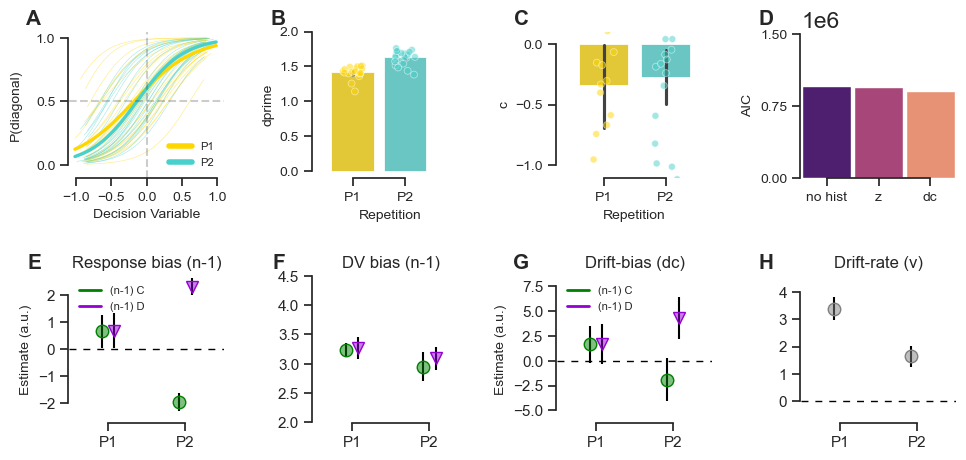

In [ ]:


EXP = 'lapse_bias'
EXP_ddm = 'lapse_sim'
best_model = 'dc'
nindividuals = 60
sizepoint = 4
rt = "v"; sigma = .5
dodge = False
mycol = colpal2

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set_palette(colpal2)

# ── Panel A [0,0]: Psychometric function ─────────────────────────────────────
axis = (0, 0)
dat = all_data[all_data.exp_bias == EXP]
nrep_labels   = np.unique(dat.nrep)
id_subj_labels = np.unique(dat.nit)

for i in range(0, nindividuals):
    dat2 = dat.loc[dat.nit == i, :]
    for cell in nrep_labels:
        sns.regplot(x="DV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                    ci=True, n_boot=1, ax=axes[axis], truncate=True,
                    line_kws={'alpha': 0.5, 'lw': 0.4}, color=colpal2[cell])

for cell in nrep_labels:
    sns.regplot(x="DV", y="Responses", data=dat.loc[dat.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                ci=True, n_boot=1, ax=axes[axis], label=cell, truncate=True,
                line_kws={'lw': 2.4}, color=colpal2[cell])

axes[axis].axvline(0, ls='--', color='black', alpha=0.2)
axes[axis].axhline(0.5, ls='--', color='black', alpha=0.2)
axes[axis].set_ylabel('P(diagonal)', fontsize=10, labelpad=10)
axes[axis].set_xlabel('Decision Variable', fontsize=10)

# Exact limits from your provided code
axes[axis].set_xlim(-1.1, 1.1);  axes[axis].set_xticks([-1, -0.5, 0, 0.5, 1])
axes[axis].set_ylim(-0.1, 1.05); axes[axis].set_yticks([0.0, 0.5, 1])

axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].tick_params(axis='y', labelsize=10)
sns.despine(ax=axes[axis], offset=0.5, trim=True)

axes[axis].legend(
    [Line2D([0], [0], color=colpal2[c], lw=4) for c in nrep_labels],
    ['P1', 'P2'], loc='lower right', fontsize=8, framealpha=0.0)

# ── Panel B [0,1]: d-prime ───────────────────────────────────────────────────
axis = (0, 1)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("dprime", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

# Exact limits from your provided code
axes[axis].set_ylim(-0.1, 2); axes[axis].set_yticks([0.0, 0.5, 1, 1.5, 2])
axes[axis].set_xlim(-0.75, 2.2)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel C [0,2]: criterion c ────────────────────────────────────────────────
axis = (0, 2)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("c", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

# Exact limits from your provided code
axes[axis].set_ylim(-1.1, 0.1); axes[axis].set_yticks([-1, -0.5, 0])
axes[axis].set_xlim(-0.75, 1.75)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel D [0,3]: Model comparison (AIC) ────────────────────────────────────
axis = (0, 3)
dat = modelsim[modelsim.exp_ID == EXP_ddm]
g = sns.barplot(dat, x='model', y='aic', hue='model',
                dodge=False, linewidth=1, palette='magma',
                ax=axes[axis], width=0.95)
axes[axis].set_xlabel(None); axes[axis].set_ylabel("AIC", fontsize=10)

# Exact limits from your provided code
axes[axis].set_ylim(0., 1.53e6); axes[axis].set_yticks([0.0, 0.75e6, 1.5e6])
axes[axis].set_xticks([0, 1, 2]); axes[axis].set_xticklabels(['no hist', 'z', 'dc'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(ax=axes[axis], offset=0.5, trim=True)

# ── Panels E & F [1,0] and [1,1]: Psychophysics regression parameters ─────────
estims = grouped_params[grouped_params.model == EXP].copy()
estims["2.5_ci"]  = estims["Estimate"] - estims["sem"] * 1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"] * 1.96

# Exact limits from your provided code
y_limits   = [[-2.7, 2.7], [2, 4.5]]
sp_titles  = ['Response bias (n-1)', 'DV bias (n-1)']
dodge_small = 0.08

for i, iparam in enumerate(['intercept', 'DV']):
    axis = (1, i)
    ax   = axes[axis]
    ax.set_title(sp_titles[i], fontsize=12)

    stim       = estims[estims.parameter == iparam]
    prev_vals  = np.unique(stim['pre_deci'])          

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['pre_deci'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['Estimate'].values
        yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
                   np.abs(subset['97.5_ci'].values - y_vals)]

        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if i == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(y_limits[i])
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if i == 0 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panels G & H [1,2] and [1,3]: DDM parameters ──────────────────────────────
# Exact limits from your provided code
y_limits  = [[-0.0, 10], [-0.5, 1]]
sp_titles = ['Drift-bias (dc)', 'Drift-rate (v)']
estims = ddms_params[
    (ddms_params.exp_ID == EXP_ddm) & (ddms_params.model == best_model)].copy()
estims['mean']   = estims['mean'].astype(float)
estims['2.5q']   = estims['2.5q'].astype(float)
estims['97.5q']  = estims['97.5q'].astype(float)

dodge_small = 0.08

for j, jparam in enumerate(['dc', 'v']):
    axis = (1, 2 + j)
    ax   = axes[axis]
    ax.set_title(sp_titles[j], fontsize=12)

    stim      = estims[estims.param == jparam]
    prev_vals = np.unique(stim['prevr'])

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['prevr'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['mean'].values
        errs    = np.array([y_vals - subset['2.5q'].values,
                            subset['97.5q'].values - y_vals])

        # Apply GREY explicitly for drift rate 'v'
        base_col = colpal3[h_idx] if jparam != 'v' else 'grey'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=errs, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if j == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    #ax.set_ylim(y_limits[j])
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if j == 0 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panel labels (A, B, C …) ──────────────────────────────────────────────────
panel_labels = list(string.ascii_uppercase)
for idx, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3696331560.py:53: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3696331560.py:55: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3696331560.py:73: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_52617/3696331560.py:75: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",


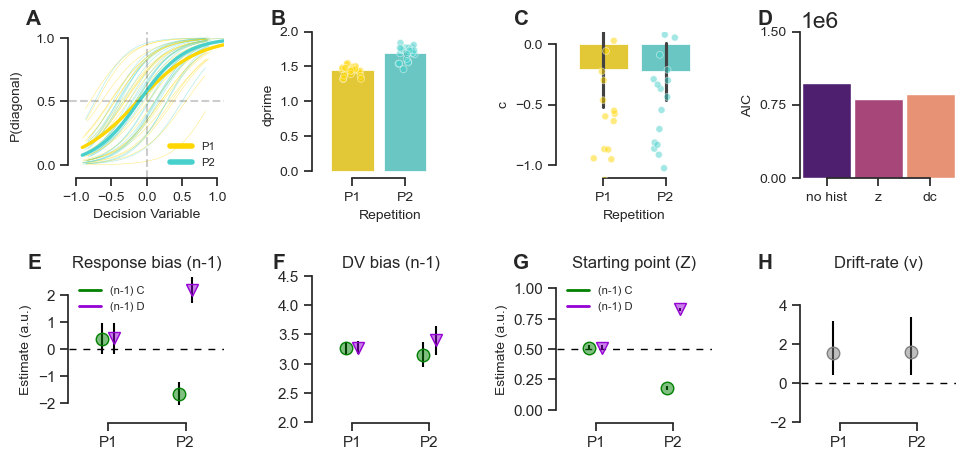

In [49]:

EXP = 'Z_bias'
EXP_ddm = 'Z_sim'
best_model = 'Z'
nindividuals = 60
sizepoint = 4
rt = "v"; sigma = .5
dodge = False
mycol = colpal2

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set_palette(colpal2)

# ── Panel A [0,0]: Psychometric function ─────────────────────────────────────
axis = (0, 0)
dat = all_data[all_data.exp_bias == EXP]
nrep_labels   = np.unique(dat.nrep)
id_subj_labels = np.unique(dat.nit)

for i in range(0, nindividuals):
    dat2 = dat.loc[dat.nit == i, :]
    for cell in nrep_labels:
        sns.regplot(x="DV", y="Responses", data=dat2.loc[dat2.nrep == cell, :],
                    logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                    ci=True, n_boot=1, ax=axes[axis], truncate=True,
                    line_kws={'alpha': 0.5, 'lw': 0.4}, color=colpal2[cell])

for cell in nrep_labels:
    sns.regplot(x="DV", y="Responses", data=dat.loc[dat.nrep == cell, :],
                logistic=True, y_jitter=0, scatter_kws={'alpha': 0},
                ci=True, n_boot=1, ax=axes[axis], label=cell, truncate=True,
                line_kws={'lw': 2.4}, color=colpal2[cell])

axes[axis].axvline(0, ls='--', color='black', alpha=0.2)
axes[axis].axhline(0.5, ls='--', color='black', alpha=0.2)
axes[axis].set_ylabel('P(diagonal)', fontsize=10, labelpad=10)
axes[axis].set_xlabel('Decision Variable', fontsize=10)

axes[axis].set_xlim(-1.1, 1.1);  axes[axis].set_xticks([-1, -0.5, 0, 0.5, 1])
axes[axis].set_ylim(-0.1, 1.05); axes[axis].set_yticks([0.0, 0.5, 1])

axes[axis].tick_params(axis='x', labelsize=10)
axes[axis].tick_params(axis='y', labelsize=10)
sns.despine(ax=axes[axis], offset=0.5, trim=True)

axes[axis].legend(
    [Line2D([0], [0], color=colpal2[c], lw=4) for c in nrep_labels],
    ['P1', 'P2'], loc='lower right', fontsize=8, framealpha=0.0)

# ── Panel B [0,1]: d-prime ───────────────────────────────────────────────────
axis = (0, 1)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("dprime", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

axes[axis].set_ylim(-0.1, 2); axes[axis].set_yticks([0.0, 0.5, 1, 1.5, 2])
axes[axis].set_xlim(-0.75, 2.2)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel C [0,2]: criterion c ────────────────────────────────────────────────
axis = (0, 2)
dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]
sns.barplot(data=dat, x="nrep", y="c", hue="nrep",
            ax=axes[axis], alpha=0.9, dodge=dodge, linewidth=0.6, palette=colpal2)
sns.stripplot(data=dat, x="nrep", y="c", hue="nrep",
              ax=axes[axis], alpha=0.5, dodge=dodge, edgecolor="white",
              linewidth=0.6, jitter=0.2, legend=False, palette=colpal2)
axes[axis].set_ylabel("c", fontsize=10)
axes[axis].set_xlabel('Repetition', fontsize=10)

axes[axis].set_ylim(-1.1, 0.1); axes[axis].set_yticks([-1, -0.5, 0])
axes[axis].set_xlim(-0.75, 1.75)
axes[axis].set_xticks([0, 1]); axes[axis].set_xticklabels(['P1', 'P2'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(offset=.5, trim=True, ax=axes[axis])

# ── Panel D [0,3]: Model comparison (AIC) ────────────────────────────────────
axis = (0, 3)
dat = modelsim[modelsim.exp_ID == EXP_ddm]
g = sns.barplot(dat, x='model', y='aic', hue='model',
                dodge=False, linewidth=1, palette='magma',
                ax=axes[axis], width=0.95)
axes[axis].set_xlabel(None); axes[axis].set_ylabel("AIC", fontsize=10)

axes[axis].set_yticks([0.0, 0.75e6, 1.5e6])
axes[axis].set_xticks([0, 1, 2]); axes[axis].set_xticklabels(['no hist', 'z', 'dc'])

axes[axis].tick_params(axis='y', labelsize=10)
axes[axis].tick_params(axis='x', labelsize=10)
if axes[axis].get_legend(): axes[axis].get_legend().remove()
sns.despine(ax=axes[axis], offset=0.5, trim=True)

# ── Panels E & F [1,0] and [1,1]: Psychophysics regression parameters ─────────
estims = grouped_params[grouped_params.model == EXP].copy()
estims["2.5_ci"]  = estims["Estimate"] - estims["sem"] * 1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"] * 1.96

psy_params = [
    ('intercept', 'Response bias (n-1)', 0, [-2.7, 2.7]), 
    ('DV', 'DV bias (n-1)', 1, [2, 4.5])
]
dodge_small = 0.08

for iparam, title, col_idx, ylims in psy_params:
    axis = (1, col_idx)
    ax   = axes[axis]
    ax.set_title(title, fontsize=12)

    stim       = estims[estims.parameter == iparam]
    prev_vals  = np.unique(stim['pre_deci'])          

    ax.axhline(y=0, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['pre_deci'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['Estimate'].values
        yerr    = [np.abs(y_vals - subset['2.5_ci'].values),
                   np.abs(subset['97.5_ci'].values - y_vals)]

        base_col = colpal3[h_idx]
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=yerr, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if col_idx == 0:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(ylims)
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if col_idx == 0 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panels G & H [1,2] and [1,3]: DDM parameters ──────────────────────────────
estims = ddms_params[
    (ddms_params.exp_ID == EXP_ddm) & (ddms_params.model == best_model)].copy()
estims['mean']   = estims['mean'].astype(float)
estims['2.5q']   = estims['2.5q'].astype(float)
estims['97.5q']  = estims['97.5q'].astype(float)

# DDM setup mapping jparam, title, column_index, ylims, and ab_line
ddm_params = [
    ('z', 'Starting point (Z)', 2, [-0.1, 1.1], 0.5), 
    ('v', 'Drift-rate (v)',     3, [-2, 5.5],   0.0)
]
dodge_small = 0.08

for jparam, title, col_idx, ylims, ab_line in ddm_params:
    axis = (1, col_idx)
    ax   = axes[axis]
    ax.set_title(title, fontsize=12)

    stim      = estims[estims.param == jparam]
    prev_vals = np.unique(stim['prevr'])

    # Apply the specific horizontal reference line for this parameter
    ax.axhline(y=ab_line, color='black', lw=1, ls='--', dashes=(5, 5))

    for h_idx, h_val in enumerate(prev_vals):
        subset  = stim[stim['prevr'] == h_val].sort_values('nrep')
        x_pos   = np.arange(len(np.unique(stim['nrep']))) + \
                  (dodge_small if h_idx == 1 else -dodge_small)

        y_vals  = subset['mean'].values
        errs    = np.array([y_vals - subset['2.5q'].values,
                            subset['97.5q'].values - y_vals])

        # Apply GREY explicitly for drift rate 'v'
        base_col = colpal3[h_idx] if jparam != 'v' else 'grey'
        face_col = mcolors.to_rgba(base_col, alpha=0.5)
        marker   = 'o' if h_idx == 0 else 'v'

        ax.errorbar(x_pos, y_vals, yerr=errs, fmt=marker,
                    color=base_col, mfc=face_col, mec=base_col,
                    markersize=9, elinewidth=1.5, ecolor='black',
                    capsize=0, zorder=10)

    if col_idx == 2:
        ax.legend(
            [Line2D([0], [0], color=colpal3[k], lw=2) for k in range(len(prev_vals))],
            ['(n-1) C', '(n-1) D'], loc='upper left', fontsize=8, framealpha=0.0)

    ax.set_ylim(ylims)
    ax.set_ylabel('Estimate (a.u.)', fontsize=10) if col_idx == 2 else ax.set_ylabel('')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['P1', 'P2'])
    ax.set_xlim([-0.5, 1.5]); ax.margins(x=0.2, y=0.2)
    ax.set_xlabel('', fontsize=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    sns.despine(ax=ax, offset=0.5, trim=True)

# ── Panel labels (A, B, C …) ──────────────────────────────────────────────────
panel_labels = list(string.ascii_uppercase)
for idx, ax in enumerate(axes.flat):
    ax.text(-0.18, 1.15, panel_labels[idx], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

fig.tight_layout()
plt.show()

/Users/alex/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:4109: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


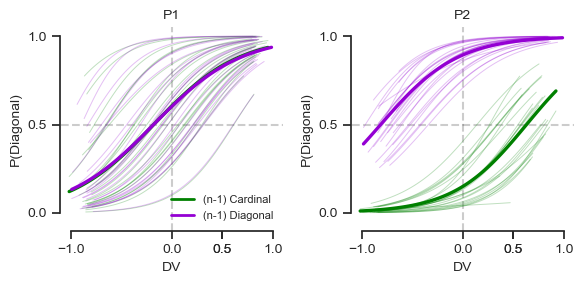

In [33]:
EXP = 'lapse_bias'

sns.set(font_scale = 1, style = 'ticks') 
mycol = colpal3
sns.set_palette(mycol)

titles = ['P1', 'P2']

dat = all_data[ (all_data.exp_bias == EXP) ]

pre_deci_labels = np.unique(dat['pre_deci'])     #pre_deci
nreps = np.unique(dat['nrep'])     #nreps
nrep_labels = np.unique(dat.nrep) #nrep
id_subj_labels = np.unique(dat.nit) #npar



fig, axes = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [.20, .20]})
#fig.suptitle("DV for previous decision for the different repetitions", fontsize=20)

labels = ['(n-1) Cardinal', '(n-1) Diagonal']; 
lines = [Line2D([0], [0], color=c, linewidth=2) for c in mycol]; 
axes[0].legend(lines, labels,loc = 'lower right', fontsize=8, framealpha= 0.0)

for j in nreps:
    axes[j].axvline(0, ls='--', color= 'black', alpha = 0.2)
    axes[j].axhline(0.5, ls='--', color= 'black', alpha = 0.2)
    for cell in pre_deci_labels:
        for i in range(0,nindividuals): #this for loop makes the plot for each participant 
            dati = dat[(dat.nit == i) & (dat['pre_deci'] == cell) & (dat.nrep == j)].copy()#df.loc[(df.npar == i) & (df['deci-1'] == cell) & (df.nrep == j),:]
            sns.regplot(x="DV", y="Responses",  data= dati,
               logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  
                              label=cell,  truncate=True, line_kws ={'alpha':0.25, 'lw':0.7}, ax = axes[j], color = mycol[cell]);

        datall = dat[(dat['pre_deci'] == cell) & (dat.nrep == j) ].copy()
        sns.regplot(x="DV", y="Responses",  data= datall,
               logistic=True, y_jitter=.0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  
                          label=cell, truncate=True, line_kws={'lw':2.4}, ax = axes[j], color = mycol[cell]);

    # Tweaking subplots
    axes[j].set_title(titles[j],fontsize = 10)

    axes[j].set_xlabel('DV', fontsize = 10)
    axes[j].set_ylabel('P(Diagonal)', fontsize = 10)

    axes[j].set_xlim(-1.1,1.1)
    axes[j].set_xticks([-1,0.5,0,0.5,1]) 

    axes[j].tick_params(axis='x', labelsize=10)   
    axes[j].set_yticks([0.0,0.5,1]) 
    axes[j].set_ylim(-0.1,1.05)
    axes[j].tick_params(axis='y', labelsize=10) 
    #axes[j].xticks(np.arange(-0.6, 0.61, step=0.3), fontsize = 25); 
    sns.despine(ax= axes[j], offset=0.5, trim = True);

dat = all_params[ (all_params.model == EXP) ]
dat = dat.melt(id_vars=['nrep', 'model', 'pre_deci','niter'], var_name='parameter', value_name='Estimate')
estims = dat.groupby([ 'nrep', 'model', 'pre_deci','parameter'],as_index=False)[['Estimate']].mean() 
aux = dat.groupby([ 'nrep', 'model', 'pre_deci','parameter'])[['Estimate']].apply(sem)
aux.reset_index(inplace=True)


fig.tight_layout()
##axes[0].ylabel('p(diagonal)', fontsize = 20, labelpad=20); axes[0].yticks(np.arange(0, 1.1, step=0.25), fontsize = 25); plt.xlabel(' ', fontsize = 0)



/Users/alex/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:4109: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


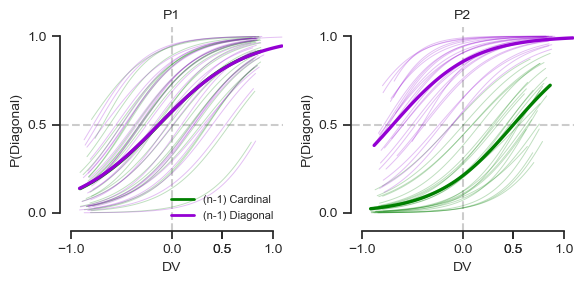

In [36]:
EXP = 'Z_bias'

sns.set(font_scale = 1, style = 'ticks') 
mycol = colpal3
sns.set_palette(mycol)

titles = ['P1', 'P2']

dat = all_data[ (all_data.exp_bias == EXP) ]

pre_deci_labels = np.unique(dat['pre_deci'])     #pre_deci
nreps = np.unique(dat['nrep'])     #nreps
nrep_labels = np.unique(dat.nrep) #nrep
id_subj_labels = np.unique(dat.nit) #npar



fig, axes = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [.20, .20]})
#fig.suptitle("DV for previous decision for the different repetitions", fontsize=20)

labels = ['(n-1) Cardinal', '(n-1) Diagonal']; 
lines = [Line2D([0], [0], color=c, linewidth=2) for c in mycol]; 
axes[0].legend(lines, labels,loc = 'lower right', fontsize=8, framealpha= 0.0)

for j in nreps:
    axes[j].axvline(0, ls='--', color= 'black', alpha = 0.2)
    axes[j].axhline(0.5, ls='--', color= 'black', alpha = 0.2)
    for cell in pre_deci_labels:
        for i in range(0,nindividuals): #this for loop makes the plot for each participant 
            dati = dat[(dat.nit == i) & (dat['pre_deci'] == cell) & (dat.nrep == j)].copy()#df.loc[(df.npar == i) & (df['deci-1'] == cell) & (df.nrep == j),:]
            sns.regplot(x="DV", y="Responses",  data= dati,
               logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  
                              label=cell,  truncate=True, line_kws ={'alpha':0.25, 'lw':0.7}, ax = axes[j], color = mycol[cell]);

        datall = dat[(dat['pre_deci'] == cell) & (dat.nrep == j) ].copy()
        sns.regplot(x="DV", y="Responses",  data= datall,
               logistic=True, y_jitter=.0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  
                          label=cell, truncate=True, line_kws={'lw':2.4}, ax = axes[j], color = mycol[cell]);

    # Tweaking subplots
    axes[j].set_title(titles[j],fontsize = 10)

    axes[j].set_xlabel('DV', fontsize = 10)
    axes[j].set_ylabel('P(Diagonal)', fontsize = 10)

    axes[j].set_xlim(-1.1,1.1)
    axes[j].set_xticks([-1,0.5,0,0.5,1]) 

    axes[j].tick_params(axis='x', labelsize=10)   
    axes[j].set_yticks([0.0,0.5,1]) 
    axes[j].set_ylim(-0.1,1.05)
    axes[j].tick_params(axis='y', labelsize=10) 
    #axes[j].xticks(np.arange(-0.6, 0.61, step=0.3), fontsize = 25); 
    sns.despine(ax= axes[j], offset=0.5, trim = True);

dat = all_params[ (all_params.model == EXP) ]
dat = dat.melt(id_vars=['nrep', 'model', 'pre_deci','niter'], var_name='parameter', value_name='Estimate')
estims = dat.groupby([ 'nrep', 'model', 'pre_deci','parameter'],as_index=False)[['Estimate']].mean() 
aux = dat.groupby([ 'nrep', 'model', 'pre_deci','parameter'])[['Estimate']].apply(sem)
aux.reset_index(inplace=True)


fig.tight_layout()
##axes[0].ylabel('p(diagonal)', fontsize = 20, labelpad=20); axes[0].yticks(np.arange(0, 1.1, step=0.25), fontsize = 25); plt.xlabel(' ', fontsize = 0)



YOU ALSO NEED TO LOAD THE DDM MODEL PARAMETERS

Threshold model

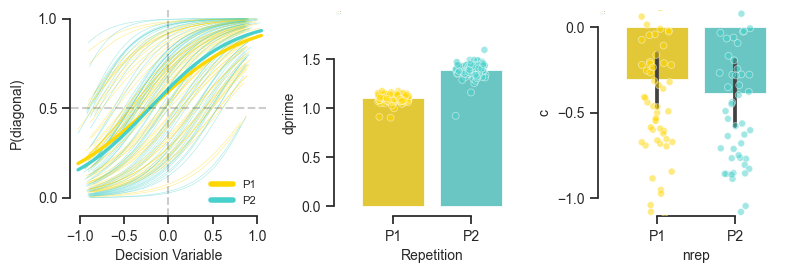

In [ ]:
EXP = 'threshold_bias'
nindividuals = 60 # how many participants you can to draw
# plotting accurary 

sizepoint = 4
rt = "v"; sigma = .5
dodge = False

mycol = colpal2


fig, axes = plt.subplots(1, 3, figsize=(8, 2.7))
fig.subplots_adjust(wspace=0.25, hspace=0)

sns.set_palette(colpal2)


dat = all_data[ (all_data.exp_bias == EXP) ]
#dat['nrep'] = dat['nrep'].cat.remove_unused_categories()

nrep_labels = np.unique(dat.nrep) #nrep
id_subj_labels = np.unique(dat.nit) #npar


for i in range(0,nindividuals): #id_subj_labels: #for loop to compute the average by each participant
    dat2=dat.loc[(dat.nit == i) ,:]
    for cell in nrep_labels:
        sns.set_palette(colpal2)
        sns.regplot(x="DV", y="Responses",  data=dat2.loc[dat2.nrep == cell,:],
           logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1, ax = axes[0], label=cell,  truncate=True, 
                         line_kws ={'alpha':0.5, 'lw':0.4}); #mean all subject

for cell in nrep_labels: #for loop to compute the plot by the average sample
    sns.set_palette(colpal2)
    sns.regplot(x="DV", y="Responses",  data=dat.loc[(dat.nrep == cell) ,:],
           logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1,   ax = axes[0], label=cell,  truncate=True, 
                     line_kws ={'lw':2.4});
#sns.despine(offset=1, trim=True, ax = axes[j]);


axes[0].axvline(0, ls ='--', color= 'black', alpha=0.2)
axes[0].axhline(0.5, ls ='--', color= 'black', alpha=0.2)


axes[0].set_ylabel('P(diagonal)', fontsize = 10, labelpad=10); #axes[j].set_yticks(np.arange(0, 1.1, step=0.25), fontsize = 15) 
axes[0].set_xlabel('Decision Variable', fontdict={'size':10}); 

axes[0].set_xlim(-1.1,1.1)
axes[0].set_xticks([-1, -0.5,0,0.5,1]) 
axes[0].tick_params(axis='x', labelsize=10)  

axes[0].set_yticks([0.0,0.5,1]) 
axes[0].set_ylim(-0.1,1.05)
axes[0].tick_params(axis='y', labelsize=10) 

sns.despine(ax= axes[0], offset=0.5, trim = True);
#'lower right', borderpad=0.1,prop={'size':10}

lines = [Line2D([0], [0], color=c, linewidth=4) for c in colpal2]; labels = ['P1', 'P2']; 
axes[0].legend(lines, labels,loc = 'lower right', fontsize=8, framealpha= 0.0)
fig.tight_layout()

# plotting dprime and criterion 

sns.set_palette(colpal2)

dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]

g = sns.barplot(data=dat, x="nrep", y="dprime", hue="nrep", ax = axes[1],alpha = 0.9, dodge=dodge,linewidth = 0.6)
g = sns.stripplot(data=dat, x="nrep", y="dprime", hue="nrep", ax = axes[1],alpha = 0.5, dodge=dodge,edgecolor = "white", linewidth=0.6, jitter = 0.2, legend = False)
g.set_xlabel("nrep",fontsize=10)
g.set_ylabel("dprime",fontsize=10)
g.legend(loc='upper left', fontsize=0,  framealpha= 0.0) #labels=['P1', 'P2', 'P3'], #


axes[1].set_ylim(-0.1,2)
axes[1].set_yticks([0.0,0.5,1, 1.5]) 
axes[1].tick_params(axis='y', labelsize=10) 

axes[1].set_xlim(-0.75,1.75)
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['P1','P2'])
axes[1].tick_params(axis='x', labelsize=10) 
axes[1].set_xlabel('Repetition', fontdict={'size':10}); 

sns.despine(offset = .5,  trim=True, ax = axes[1]);

#g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15 )

dat = group_sdt_avg[group_sdt_avg.exp_bias == EXP]

g = sns.barplot(data=dat, x="nrep", y="c", hue="nrep", ax = axes[2],alpha = 0.9, dodge=dodge,linewidth = 0.6)
g = sns.stripplot(data=dat, x="nrep", y="c", hue="nrep", ax = axes[2],alpha = 0.5, dodge=dodge,edgecolor = "white", linewidth=0.6,jitter = 0.2, legend = False)
# y axis format
axes[2].set_ylim(-1.1, 0.1)
axes[2].set_yticks([-1,-0.5,0]) 
axes[2].tick_params(axis='y', labelsize=10) 

axes[2].set_xlim(-0.75,1.75)
axes[2].set_xticks([0,1])
axes[2].set_xticklabels(['P1','P2'])
axes[2].tick_params(axis='x', labelsize=10) 
axes[2].set_xlabel('Repetition', fontdict={'size':10}); 

# x axis format
#axes[2].tick_params(axis='x', labelsize=10) 
sns.despine(offset = .5,  trim=True, ax = axes[2]);
g.set_xlabel("nrep",fontsize=10)
g.set_ylabel("c",fontsize=10)
g.legend(loc='upper left', fontsize=0,  framealpha= 0.0) #labels=['P1', 'P2', 'P3'], 
#g.set(yaxis['ylim'], yaxis['yticks'])   
fig.tight_layout(pad=0.5)
#figpath = os.path.join(figures_path, 'CJ_performance.pdf')

dx = 'exp_ID'; dy = 'aic'; hue = 'model'; 
pal = 'magma' #['black', 'blue', 'orange', 'green']
dat = modelsim[modelsim.exp_ID == 'lapse_sim']



#plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_99045/948641766.py:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="pre_deci",linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_99045/948641766.py:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="pre_deci",linestyles='',


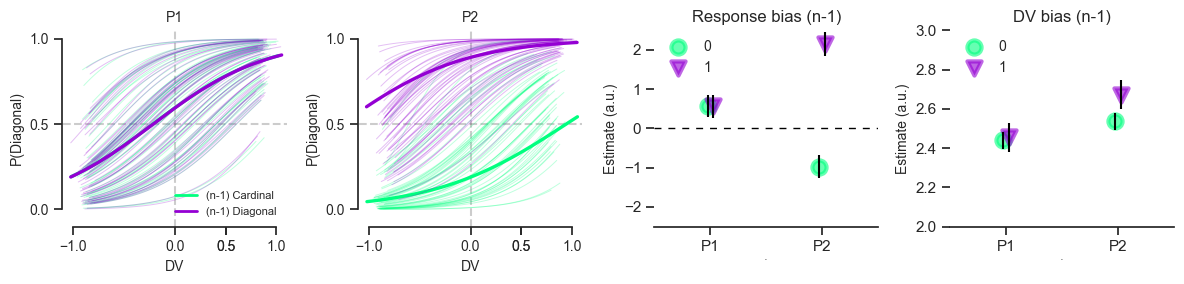

In [ ]:
EXP = 'threshold_bias'

sns.set(font_scale = 1, style = 'ticks') 
mycol = colpal3
sns.set_palette(mycol)

titles = ['P1', 'P2']

dat = all_data[ (all_data.exp_bias == EXP) ]

pre_deci_labels = np.unique(dat['pre_deci'])     #pre_deci
nreps = np.unique(dat['nrep'])     #nreps
nrep_labels = np.unique(dat.nrep) #nrep
id_subj_labels = np.unique(dat.nit) #npar



fig, axes = plt.subplots(1, 4, figsize=(12, 3), gridspec_kw={'width_ratios': [.20, .20,.20,.20]})
#fig.suptitle("DV for previous decision for the different repetitions", fontsize=20)

labels = ['(n-1) Cardinal', '(n-1) Diagonal']; 
lines = [Line2D([0], [0], color=c, linewidth=2) for c in mycol]; 
axes[0].legend(lines, labels,loc = 'lower right', fontsize=8, framealpha= 0.0)

for j in nreps:
    axes[j].axvline(0, ls='--', color= 'black', alpha = 0.2)
    axes[j].axhline(0.5, ls='--', color= 'black', alpha = 0.2)
    for cell in pre_deci_labels:
        for i in range(0,nindividuals): #this for loop makes the plot for each participant 
            dati = dat[(dat.nit == i) & (dat['pre_deci'] == cell) & (dat.nrep == j)].copy()#df.loc[(df.npar == i) & (df['deci-1'] == cell) & (df.nrep == j),:]
            sns.regplot(x="DV", y="Responses",  data= dati,
               logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  
                              label=cell,  truncate=True, line_kws ={'alpha':0.25, 'lw':0.7}, ax = axes[j], color = mycol[cell]);

        datall = dat[(dat['pre_deci'] == cell) & (dat.nrep == j) ].copy()
        sns.regplot(x="DV", y="Responses",  data= datall,
               logistic=True, y_jitter=.0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  
                          label=cell, truncate=True, line_kws={'lw':2.4}, ax = axes[j], color = mycol[cell]);

    # Tweaking subplots
    axes[j].set_title(titles[j],fontsize = 10)

    axes[j].set_xlabel('DV', fontsize = 10)
    axes[j].set_ylabel('P(Diagonal)', fontsize = 10)

    axes[j].set_xlim(-1.1,1.1)
    axes[j].set_xticks([-1,0.5,0,0.5,1]) 

    axes[j].tick_params(axis='x', labelsize=10)   
    axes[j].set_yticks([0.0,0.5,1]) 
    axes[j].set_ylim(-0.1,1.05)
    axes[j].tick_params(axis='y', labelsize=10) 
    #axes[j].xticks(np.arange(-0.6, 0.61, step=0.3), fontsize = 25); 
    sns.despine(ax= axes[j], offset=0.5, trim = True);

dat = all_params[ (all_params.model == EXP) ]
dat = dat.melt(id_vars=['nrep', 'model', 'pre_deci','niter'], var_name='parameter', value_name='Estimate')
estims = dat.groupby([ 'nrep', 'model', 'pre_deci','parameter'],as_index=False)[['Estimate']].mean() 
aux = dat.groupby([ 'nrep', 'model', 'pre_deci','parameter'])[['Estimate']].apply(sem)
aux.reset_index(inplace=True)
estims['sem'] = aux['sem']


# Confidence Intervals
estims["2.5_ci"] = estims["Estimate"] - estims["sem"]*1.96
estims["97.5_ci"] = estims["Estimate"] + estims["sem"]*1.96


x_limits = np.array([[-2.5, 2.5] ,[2, 3]])

sp_titles = ['Response bias (n-1)','DV bias (n-1)']

for i, iparam in enumerate(['intercept','DV']):
    #i = i + 2
    axes[i+2].set_title(sp_titles[i], fontsize=12)
    stim = estims[estims.parameter == iparam]
    g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="pre_deci",linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i+2])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    for point_pair in axes[i+2].collections:
        for x, y in point_pair.get_offsets():
            x_coords.append(x)
            y_coords.append(y)

    axes[i+2].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

    axes[i+2].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
    fmt=' ', zorder=3, ecolor = 'black')
    axes[i+2].spines['top'].set_visible(False)
    axes[i+2].spines['right'].set_visible(False)
    axes[i+2].spines['left'].set_visible(False)

    axes[i+2].legend(loc='upper left', borderpad=0.2,prop={'size':10}, fontsize=12,  framealpha= 0.0)

    axes[i+2].margins(y=0.2)
    axes[i+2].set_ylim(x_limits[i])

    axes[i+2].set_xlabel('nrep', fontsize = 0)
    axes[i+2].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i+2].set_xlim([-0.5,1.5])
    axes[i+2].margins(x=0.2)
    axes[i+2].set_xticks([0,1])
    axes[i+2].set_xticklabels(['P1', 'P2'])
    axes[i+2].tick_params(axis='y', labelsize=11) 
    axes[i+2].tick_params(axis='x', labelsize=11) 


fig.tight_layout()
##axes[0].ylabel('p(diagonal)', fontsize = 20, labelpad=20); axes[0].yticks(np.arange(0, 1.1, step=0.25), fontsize = 25); plt.xlabel(' ', fontsize = 0)



 # Preparing models comparison

<AxesSubplot: xlabel='model', ylabel='aic'>

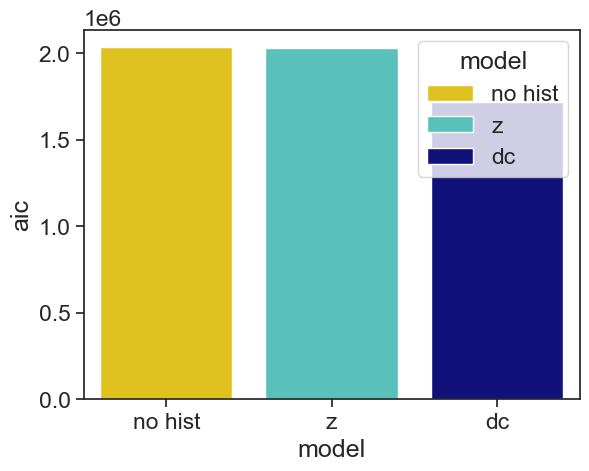

In [149]:
dx = 'model'; dy = 'aic'; hue = 'model'; 
pal = 'magma' #['black', 'blue', 'orange', 'green']
dat = modelsim[modelsim.exp_ID == 'lapse_sim']

sns.barplot(dat, x=dx, y=dy, hue = hue, dodge=False,linewidth = 1)


# HDDM parameters

In [30]:
def aic_diff(X):
    ref = X[X.model == 'no hist'].aic
    dat = X
    dat['aic'] = dat.aic -  ref.iloc[0]
    return dat


In [116]:
AIC_rel = modelfit.groupby('exp_ID').apply(aic_diff).reset_index()
AIC_rel = AIC_rel[(AIC_rel.model != 'no hist') & (AIC_rel.model != 'zXdcrepeat')]
AIC_rel['model'] = AIC_rel['model'].cat.remove_unused_categories()

In [117]:
modelfit

,exp_ID,model,fiteddata,aic,bic
0,3reps,dc,real,2.500215e+04,2.770284e+04
1,3reps,no hist,real,3.151879e+04,3.332975e+04
2,3reps,zXdc,real,4.087852e+04,4.686559e+04
3,3reps,z,real,3.011817e+04,3.259053e+04
4,3reps_lag,dc,real,4.153377e+04,4.814530e+04
5,3reps_lag,no hist,real,4.660782e+04,4.946475e+04
6,3reps_lag,zXdc,real,4.206286e+04,5.273341e+04
7,3reps_lag,z,real,4.472188e+04,5.101337e+04
8,CJ,dc,real,3.259849e+04,3.567129e+04
9,CJ,zXdcrepeat,real,3.305530e+04,3.847656e+04


Lets plot DC model for main effects. Based on interaction models.
Them plot changes in drift rate based on single stim fits

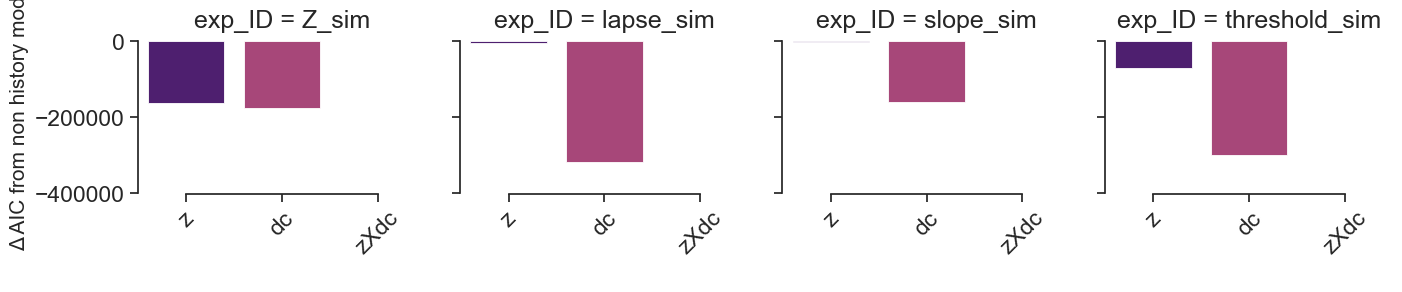

In [104]:

sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] = 1.2
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'Δ AIC from non history model'
#yaxis = {'ya':[-5000,10000]};  yaxis['yticks']=[-2, 0, 2, 4]
yaxis = [-400000,15000] # None# [-100,2000]
dx = 'model'; dy = 'aic'; hue = 'model';  row = None; col = 'exp_ID'
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot_models(AIC_rel[AIC_rel.fiteddata == 'simulated'], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)

#figpath = os.path.join(figures_path, '3reps_modelperformance.pdf')
#plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


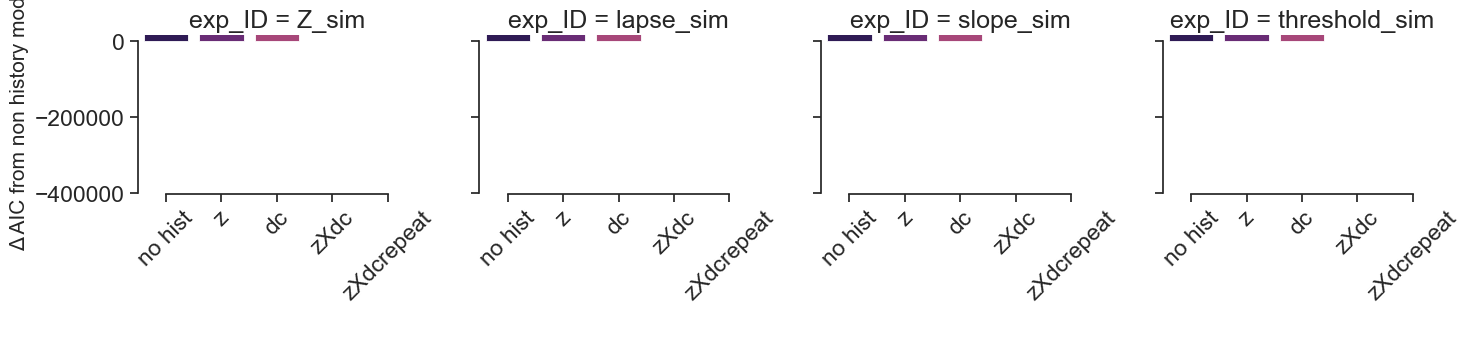

In [105]:

sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] = 1.2
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'Δ AIC from non history model'
#yaxis = {'ya':[-5000,10000]};  yaxis['yticks']=[-2, 0, 2, 4]
yaxis = [-400000,15000] # None# [-100,2000]
dx = 'model'; dy = 'aic'; hue = 'model';  row = None; col = 'exp_ID'
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot_models(modelfit[modelfit.fiteddata == 'simulated'], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)

#figpath = os.path.join(figures_path, '3reps_modelperformance.pdf')
#plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


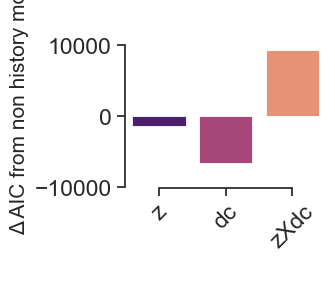

In [46]:

sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] = 1.2
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'Δ AIC from non history model'
#yaxis = {'ya':[-5000,10000]};  yaxis['yticks']=[-2, 0, 2, 4]
yaxis = [-10000,15000] # None# [-100,2000]
dx = 'model'; dy = 'aic'; hue = 'model';  row = None; col = None
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot_models(dat, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)

figpath = os.path.join(figures_path, '3reps_modelperformance.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


In [47]:
modelidx_CJ = modelfit[(modelfit.model != 'zXdcrepeat') & (modelfit.exp_ID =='CJ')]
ref = modelidx_CJ[modelidx_CJ.model == 'no hist'].aic
dat = modelidx_CJ[modelidx_CJ.model != 'no hist']
dat['aic'] = dat.aic -  ref.iloc[0]
dat['model'] = dat['model'].cat.remove_unused_categories()


/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_32608/2726605845.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['aic'] = dat.aic -  ref.iloc[0]
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_32608/2726605845.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['model'] = dat['model'].cat.remove_unused_categories()


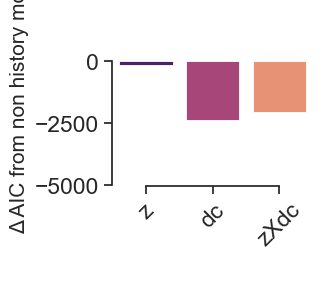

In [48]:

sizeplot = {}; sizeplot['height'] = 3; sizeplot['aspect'] = 1.2
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'Δ AIC from non history model'
#yaxis = {'ya':[-5000,10000]};  yaxis['yticks']=[-2, 0, 2, 4]
yaxis = [-5000,2100] # None# [-100,2000]
dx = 'model'; dy = 'aic'; hue = 'model';  row = None; col = None
pal = 'magma' #['black', 'blue', 'orange', 'green']

barsplot_models(dat, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)

figpath = os.path.join(figures_path, 'CJ_modelperformance.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


__3reps dc__

In [945]:
params

['v', 'z']

In [261]:

y_limits = np.array([[-0.5, 1] ,[-0.5, 1],[-2.2, 2.1]])
estims = params[(params.exp_ID == '3reps' ) & (params.model == 'stimcoding_dc_prevresp')]
estims['mean'] = estims['mean'].astype(float)
estims['2.5q'] = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)


fig, axes = plt.subplots(1, 3, figsize=(8,2.5))
fig.tight_layout(pad=1)

sp_titles = ['Starting point (z)','Drift-rate (v)' ,'Drift-bias (dc)']

for iexp, exp in enumerate(['3reps']):

        for j, jparam in enumerate(['z','v','dc']):

            axes[j].set_title(sp_titles[j], fontsize=12)
            

            stim = estims[(estims.param == jparam) ]
            g = sns.pointplot(data=stim, x="nrep" , y="mean" , hue="prevr",linestyles='', 
            dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[j])


            
            plt.setp(g.collections, alpha=.6) # set alpha for all points

            # Find the x,y coordinates for each point
            x_coords = []
            y_coords = []
            for point_pair in axes[j].collections:
                for x, y in point_pair.get_offsets():
                    x_coords.append(x)
                    y_coords.append(y)
            x_coords = np.ma.compressed(x_coords) # eliminate masked values
            y_coords = np.ma.compressed(y_coords)

            
        
            errs = np.array(stim[["2.5q","97.5q"]]).T
            errs[0,:] = stim['mean'] - errs[0,:]  
            errs[1,:] = errs[1,:] - stim['mean']
   
            axes[j].errorbar(x_coords, y_coords, yerr=errs, #errs
            fmt=' ', zorder=3, ecolor = 'black')
            
            axes[j].spines['top'].set_visible(False)
            axes[j].spines['right'].set_visible(False)
            axes[j].spines['left'].set_visible(False)

            axes[j].legend(loc='upper left', borderpad=0.2,prop={'size':10}, fontsize=12,  framealpha= 0.0)

            axes[j].margins(y=0.1)
            

            #axes[i].set_xticklabels(['P1', 'P2', 'P3'])

            axes[j].set_xlabel('nrep', fontsize = 0)
            axes[j].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

            axes[j].set_xticks([0,1,2])
            axes[j].set_xticklabels(['P1', 'P2', 'P3'])

            ylab = np.linspace(-1, 2, num=7)
            axes[j].set_yticks( [-2,-1,0,1,2])
            #axes[i,j].set_yticklabels( ylab)
            axes[j].set_ylim(y_limits[j])
            #axes[i,j].set_ylim([-3,3])
            
            
            axes[j].tick_params(axis='y', labelsize=11) 
            axes[j].tick_params(axis='x', labelsize=11) 
            axes[j].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

            
figpath = os.path.join(figures_path, '3reps_hddmDC.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)

            

NameError: name 'params' is not defined

__CJ dc__

__CJ repetition__

<ipython-input-1054-ab00e25f4704>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estims['mean'] = estims['mean'].astype(float)
<ipython-input-1054-ab00e25f4704>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estims['2.5q'] = estims['2.5q'].astype(float)
<ipython-input-1054-ab00e25f4704>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

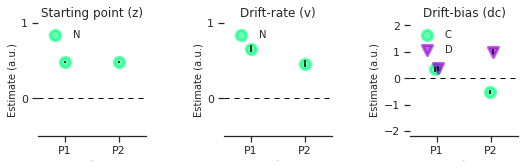

In [1054]:

y_limits = np.array([[-0.5, 1] ,[-0.5, 1],[-2.2, 2.1]])
estims = params[(params.exp_ID == 'CJ' ) & (params.model == 'stimcoding_dc_prevresp')]
estims['mean'] = estims['mean'].astype(float)
estims['2.5q'] = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)


fig, axes = plt.subplots(1, 3, figsize=(8,2.5))
fig.tight_layout(pad=1)

sp_titles = ['Starting point (z)','Drift-rate (v)' ,'Drift-bias (dc)']

for iexp, exp in enumerate(['3reps']):

        for j, jparam in enumerate(['z','v','dc']):

            axes[j].set_title(sp_titles[j], fontsize=12)
            

            stim = estims[(estims.param == jparam) ]
            g = sns.pointplot(data=stim, x="nrep" , y="mean" , hue="prevr",linestyles='', 
            dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[j])


            
            plt.setp(g.collections, alpha=.6) # set alpha for all points

            # Find the x,y coordinates for each point
            x_coords = []
            y_coords = []
            for point_pair in axes[j].collections:
                for x, y in point_pair.get_offsets():
                    x_coords.append(x)
                    y_coords.append(y)
            x_coords = np.ma.compressed(x_coords) # eliminate masked values
            y_coords = np.ma.compressed(y_coords)

            
        
            errs = np.array(stim[["2.5q","97.5q"]]).T
            errs[0,:] = stim['mean'] - errs[0,:]  
            errs[1,:] = errs[1,:] - stim['mean']
   
            axes[j].errorbar(x_coords, y_coords, yerr=errs, #errs
            fmt=' ', zorder=3, ecolor = 'black')
            
            axes[j].spines['top'].set_visible(False)
            axes[j].spines['right'].set_visible(False)
            axes[j].spines['left'].set_visible(False)

            axes[j].legend(loc='upper left', borderpad=0.2,prop={'size':10}, fontsize=12,  framealpha= 0.0)

            axes[j].margins(y=0.1)
            

            #axes[i].set_xticklabels(['P1', 'P2', 'P3'])

            axes[j].set_xlabel('nrep', fontsize = 0)
            axes[j].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

            axes[j].set_xticks([0,1])
            axes[j].set_xticklabels(['P1', 'P2'])

            ylab = np.linspace(-1, 2, num=7)
            axes[j].set_yticks( [-2,-1,0,1,2])
            #axes[i,j].set_yticklabels( ylab)
            axes[j].set_ylim(y_limits[j])
            axes[j].set_xlim([-0.5,1.5])
            #axes[i,j].set_ylim([-3,3])
            
            
            axes[j].tick_params(axis='y', labelsize=11) 
            axes[j].tick_params(axis='x', labelsize=11) 
            axes[j].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

            
figpath = os.path.join(figures_path, 'CJ_hddmDC.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)

            

__3reps_lag dc__

In [699]:

y_limits = np.array([[-0.5, 1] ,[-0.5, 1],[-1.5, 1.7]])
estims = params[(params.exp_ID == '3reps_lag' ) & (params.model == 'stimcoding_dc_prevresp')]
estims['mean'] = estims['mean'].astype(float)
estims['2.5q'] = estims['2.5q'].astype(float)
estims['97.5q'] = estims['97.5q'].astype(float)


fig, axes = plt.subplots(2, 3, figsize=(12,10))
fig.tight_layout(pad=2)

sp_titles = ['Response bias (n-1)','Drift-rate' ,'Drift-bias']
lag = ['250','3500']

for iexp, exp in enumerate(['3reps_lag']):
    for i, ilag in enumerate(lag):
        for j, jparam in enumerate(['z','v','dc']):

            axes[i, j].set_title(sp_titles[j], fontsize=12)
            
            if jparam == 'z':
                stim = estims[(estims.param == jparam) ]
                g = sns.pointplot(data=stim, x="nrep" , y="mean" , hue="prevr",linestyles='', 
                dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i,j])
            else:
                stim = estims[(estims.param == jparam) & (estims.lag == ilag)]
                g = sns.pointplot(data=stim, x="nrep" , y="mean"  , hue="prevr",linestyles='', 
                dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i,j])
                

            
            plt.setp(g.collections, alpha=.6) # set alpha for all points

            # Find the x,y coordinates for each point
            x_coords = []
            y_coords = []
            for point_pair in axes[i,j].collections:
                for x, y in point_pair.get_offsets():
                    x_coords.append(x)
                    y_coords.append(y)
            x_coords = np.ma.compressed(x_coords) # eliminate masked values
            y_coords = np.ma.compressed(y_coords)

            
        
            errs = np.array(stim[["2.5q","97.5q"]]).T
            errs[0,:] = stim['mean'] - errs[0,:]  
            errs[1,:] = errs[1,:] - stim['mean']
   
            axes[i,j].errorbar(x_coords, y_coords, yerr=errs, #errs
            fmt=' ', zorder=3, ecolor = 'black')
            
            axes[i,j].spines['top'].set_visible(False)
            axes[i,j].spines['right'].set_visible(False)
            axes[i,j].spines['left'].set_visible(False)

            axes[i,j].legend(loc='upper left', borderpad=0.2,prop={'size':10}, fontsize=12,  framealpha= 0.0)

            axes[i,j].margins(y=0.1)
            

            #axes[i].set_xticklabels(['P1', 'P2', 'P3'])

            axes[i,j].set_xlabel('nrep', fontsize = 0)
            axes[i,j].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

            axes[i,j].set_xticks([0,1,2])
            axes[i,j].set_xticklabels(['P1', 'P2', 'P3'])

            ylab = np.linspace(-1, 2, num=7)
            axes[i,j].set_yticks( ylab)
            #axes[i,j].set_yticklabels( ylab)
            axes[i,j].set_ylim(y_limits[j])
            #axes[i,j].set_ylim([-3,3])
            
            
            axes[i,j].tick_params(axis='y', labelsize=11) 
            axes[i,j].tick_params(axis='x', labelsize=11) 
            axes[i, j].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))
            


AttributeError: 'list' object has no attribute 'exp_ID'

# HDDM Stimuli regression parameters

In [99]:
exp_IDs

['3reps', 'CJ', '3reps_lag']

In [374]:
model_filename+'_fm.db'

'/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/Group_level_analyses/hddm_models/stimcoding_diffprev_3reps_fm.db'

In [708]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
models_reg = {}

exp_IDS = ['3reps','CJ', '3reps_lag']
model_name = ['stimcoding_weights','stimcoding_diffprev']
for exp in exp_IDs:
    models_reg[exp] = {}
    
    for mod_name in model_name:
        models_reg[exp][mod_name] = {}
        try:
            model_filename  = os.path.join(hddm_m_path, mod_name+'_'+exp)       
            file = open(model_filename+'_fm.db','rb')
        except:
            print('exception')
        model_file = pickle.load(file)
        file.close()
        models_reg[exp][mod_name] = model_file  #hddm.load(model_filename+'_fm.db')
        

hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
models_stim = {}
exp = '3reps'
mod_name = 'stimcoding_diffprev'#'stimcoding_weights'
models_stim[exp] = {}
    
try:
    model_filename  = os.path.join(hddm_m_path, mod_name+'_'+exp)       
    file = open(model_filename+'_fm.db','rb')
    model_file = pickle.load(file)
except:
    print('exception')
file.close()
models_stim[exp][mod_name] = model_file  #hddm.load(model_filename+'_fm.db')

In [755]:
def get_reg_params(models, exp, mod_name):
    coef = models[exp][mod_name].gen_stats()
    if mod_name == 'stimcoding_diffprev':
        z = coef.loc[['z_Intercept','z_response1','z_C(nrep)[T.1]','z_response1:C(nrep)[T.1]'], ['mean','2.5q','97.5q']]
        base_val = z.iloc[0,0]
        z['nrep'] = np.array([0,0,1,1])
        z['prevr'] = np.array([0,1,0,1])
        z['pos'] = 'N'
        z['param'] = 'z'
        z['2.5q'] = z['2.5q'] - z['mean']  
        z['97.5q'] = z['97.5q'] - z['mean']  
        z['mean'] = z['mean']  + base_val
        z.iloc[0,0] = z.iloc[0,0] - base_val
        
        if exp != 'CJ':        
            z = coef.loc[['z_Intercept','z_response1','z_C(nrep)[T.1]','z_response1:C(nrep)[T.1]','z_C(nrep)[T.2]','z_response1:C(nrep)[T.2]'], ['mean','2.5q','97.5q']]
            base_val = z.iloc[0,0]
            z['nrep'] = np.array([0,0,1,1,2,2])
            z['prevr'] = np.array([0,1,0,1,0,1])
            z['pos'] = 'N'
            z['param'] = 'z'
            z['2.5q'] = z['2.5q'] - z['mean']  
            z['97.5q'] = z['97.5q'] - z['mean']  
            z['mean'] = z['mean']  + base_val
            z.iloc[0,0] = z.iloc[0,0] - base_val


        #v_Intercept
        base_val = coef.loc['v_Intercept']['mean']

        v0 = coef.loc[['v_G1sim:C(nrep)[0]','v_G2sim:C(nrep)[0]','v_G3sim:C(nrep)[0]','v_G4sim:C(nrep)[0]','v_G5sim:C(nrep)[0]','v_G6sim:C(nrep)[0]'], ['mean','2.5q','97.5q']]
        v0['nrep'] = 0
        v0['prevr'] = 'N'
        v0['pos'] = np.array([1,2,3,4,5,6])
        v0['param'] = 'v'
        v0['2.5q'] = v0['2.5q'] - v0['mean']  
        v0['97.5q'] = v0['97.5q'] - v0['mean']  
        v0['mean']  = v0['mean']  + base_val 

        v1 = coef.loc[['v_G1sim:C(nrep)[1]','v_G2sim:C(nrep)[1]','v_G3sim:C(nrep)[1]','v_G4sim:C(nrep)[1]','v_G5sim:C(nrep)[1]','v_G6sim:C(nrep)[1]'], ['mean','2.5q','97.5q']]
        v1['nrep'] = 1
        v1['prevr'] = 'N'
        v1['pos'] = np.array([1,2,3,4,5,6])
        v1['param'] = 'v'
        v1['2.5q'] = v1['2.5q'] - v1['mean']  
        v1['97.5q'] = v1['97.5q'] - v1['mean']
        v1['mean']  = v1['mean']  + base_val 
        pars = pd.concat([z,v0,v1])
        pars['model'] = mod_name
        pars['exp'] = exp

        if exp != 'CJ':

            v2 = coef.loc[['v_G1sim:C(nrep)[2]','v_G2sim:C(nrep)[2]','v_G3sim:C(nrep)[2]','v_G4sim:C(nrep)[2]','v_G5sim:C(nrep)[2]','v_G6sim:C(nrep)[2]'], ['mean','2.5q','97.5q']]
            v2['nrep'] = 2
            v2['prevr'] = 'N'
            v2['pos'] = np.array([1,2,3,4,5,6])
            v2['param'] = 'v'
            v2['2.5q'] = v2['2.5q'] - v2['mean']  
            v2['97.5q'] = v2['97.5q'] - v2['mean']
            v2['mean']  = v2['mean']  + base_val 
            pars = pd.concat([z,v0,v1,v2])
            pars['model'] = mod_name
            pars['exp'] = exp
        return(pars)




# Models with interactions with other variables

In [755]:
def get_reg_params(models, exp, mod_name):
    coef = models[exp][mod_name].gen_stats()
    if mod_name == 'stimcoding_diffprev':
        z = coef.loc[['z_Intercept','z_response1','z_C(nrep)[T.1]','z_response1:C(nrep)[T.1]'], ['mean','2.5q','97.5q']]
        base_val = z.iloc[0,0]
        z['nrep'] = np.array([0,0,1,1])
        z['prevr'] = np.array([0,1,0,1])
        z['pos'] = 'N'
        z['param'] = 'z'
        z['2.5q'] = z['2.5q'] - z['mean']  
        z['97.5q'] = z['97.5q'] - z['mean']  
        z['mean'] = z['mean']  + base_val
        z.iloc[0,0] = z.iloc[0,0] - base_val
        
        if exp != 'CJ':        
            z = coef.loc[['z_Intercept','z_response1','z_C(nrep)[T.1]','z_response1:C(nrep)[T.1]','z_C(nrep)[T.2]','z_response1:C(nrep)[T.2]'], ['mean','2.5q','97.5q']]
            base_val = z.iloc[0,0]
            z['nrep'] = np.array([0,0,1,1,2,2])
            z['prevr'] = np.array([0,1,0,1,0,1])
            z['pos'] = 'N'
            z['param'] = 'z'
            z['2.5q'] = z['2.5q'] - z['mean']  
            z['97.5q'] = z['97.5q'] - z['mean']  
            z['mean'] = z['mean']  + base_val
            z.iloc[0,0] = z.iloc[0,0] - base_val


        #v_Intercept
        base_val = coef.loc['v_Intercept']['mean']

        v0 = coef.loc[['v_G1sim:C(nrep)[0]','v_G2sim:C(nrep)[0]','v_G3sim:C(nrep)[0]','v_G4sim:C(nrep)[0]','v_G5sim:C(nrep)[0]','v_G6sim:C(nrep)[0]'], ['mean','2.5q','97.5q']]
        v0['nrep'] = 0
        v0['prevr'] = 'N'
        v0['pos'] = np.array([1,2,3,4,5,6])
        v0['param'] = 'v'
        v0['2.5q'] = v0['2.5q'] - v0['mean']  
        v0['97.5q'] = v0['97.5q'] - v0['mean']  
        v0['mean']  = v0['mean']  + base_val 

        v1 = coef.loc[['v_G1sim:C(nrep)[1]','v_G2sim:C(nrep)[1]','v_G3sim:C(nrep)[1]','v_G4sim:C(nrep)[1]','v_G5sim:C(nrep)[1]','v_G6sim:C(nrep)[1]'], ['mean','2.5q','97.5q']]
        v1['nrep'] = 1
        v1['prevr'] = 'N'
        v1['pos'] = np.array([1,2,3,4,5,6])
        v1['param'] = 'v'
        v1['2.5q'] = v1['2.5q'] - v1['mean']  
        v1['97.5q'] = v1['97.5q'] - v1['mean']
        v1['mean']  = v1['mean']  + base_val 
        pars = pd.concat([z,v0,v1])
        pars['model'] = mod_name
        pars['exp'] = exp

        if exp != 'CJ':

            v2 = coef.loc[['v_G1sim:C(nrep)[2]','v_G2sim:C(nrep)[2]','v_G3sim:C(nrep)[2]','v_G4sim:C(nrep)[2]','v_G5sim:C(nrep)[2]','v_G6sim:C(nrep)[2]'], ['mean','2.5q','97.5q']]
            v2['nrep'] = 2
            v2['prevr'] = 'N'
            v2['pos'] = np.array([1,2,3,4,5,6])
            v2['param'] = 'v'
            v2['2.5q'] = v2['2.5q'] - v2['mean']  
            v2['97.5q'] = v2['97.5q'] - v2['mean']
            v2['mean']  = v2['mean']  + base_val 
            pars = pd.concat([z,v0,v1,v2])
            pars['model'] = mod_name
            pars['exp'] = exp
        return(pars)




In [755]:
def get_reg_params(models, exp, mod_name):
    coef = models[exp][mod_name].gen_stats()
    if mod_name == 'stimcoding_diffprev':
        z = coef.loc[['z_Intercept','z_response1','z_C(nrep)[T.1]','z_response1:C(nrep)[T.1]'], ['mean','2.5q','97.5q']]
        base_val = z.iloc[0,0]
        z['nrep'] = np.array([0,0,1,1])
        z['prevr'] = np.array([0,1,0,1])
        z['pos'] = 'N'
        z['param'] = 'z'
        z['2.5q'] = z['2.5q'] - z['mean']  
        z['97.5q'] = z['97.5q'] - z['mean']  
        z['mean'] = z['mean']  + base_val
        z.iloc[0,0] = z.iloc[0,0] - base_val
        
        if exp != 'CJ':        
            z = coef.loc[['z_Intercept','z_response1','z_C(nrep)[T.1]','z_response1:C(nrep)[T.1]','z_C(nrep)[T.2]','z_response1:C(nrep)[T.2]'], ['mean','2.5q','97.5q']]
            base_val = z.iloc[0,0]
            z['nrep'] = np.array([0,0,1,1,2,2])
            z['prevr'] = np.array([0,1,0,1,0,1])
            z['pos'] = 'N'
            z['param'] = 'z'
            z['2.5q'] = z['2.5q'] - z['mean']  
            z['97.5q'] = z['97.5q'] - z['mean']  
            z['mean'] = z['mean']  + base_val
            z.iloc[0,0] = z.iloc[0,0] - base_val


        #v_Intercept
        base_val = coef.loc['v_Intercept']['mean']

        v0 = coef.loc[['v_G1sim:C(nrep)[0]','v_G2sim:C(nrep)[0]','v_G3sim:C(nrep)[0]','v_G4sim:C(nrep)[0]','v_G5sim:C(nrep)[0]','v_G6sim:C(nrep)[0]'], ['mean','2.5q','97.5q']]
        v0['nrep'] = 0
        v0['prevr'] = 'N'
        v0['pos'] = np.array([1,2,3,4,5,6])
        v0['param'] = 'v'
        v0['2.5q'] = v0['2.5q'] - v0['mean']  
        v0['97.5q'] = v0['97.5q'] - v0['mean']  
        v0['mean']  = v0['mean']  + base_val 

        v1 = coef.loc[['v_G1sim:C(nrep)[1]','v_G2sim:C(nrep)[1]','v_G3sim:C(nrep)[1]','v_G4sim:C(nrep)[1]','v_G5sim:C(nrep)[1]','v_G6sim:C(nrep)[1]'], ['mean','2.5q','97.5q']]
        v1['nrep'] = 1
        v1['prevr'] = 'N'
        v1['pos'] = np.array([1,2,3,4,5,6])
        v1['param'] = 'v'
        v1['2.5q'] = v1['2.5q'] - v1['mean']  
        v1['97.5q'] = v1['97.5q'] - v1['mean']
        v1['mean']  = v1['mean']  + base_val 
        pars = pd.concat([z,v0,v1])
        pars['model'] = mod_name
        pars['exp'] = exp

        if exp != 'CJ':

            v2 = coef.loc[['v_G1sim:C(nrep)[2]','v_G2sim:C(nrep)[2]','v_G3sim:C(nrep)[2]','v_G4sim:C(nrep)[2]','v_G5sim:C(nrep)[2]','v_G6sim:C(nrep)[2]'], ['mean','2.5q','97.5q']]
            v2['nrep'] = 2
            v2['prevr'] = 'N'
            v2['pos'] = np.array([1,2,3,4,5,6])
            v2['param'] = 'v'
            v2['2.5q'] = v2['2.5q'] - v2['mean']  
            v2['97.5q'] = v2['97.5q'] - v2['mean']
            v2['mean']  = v2['mean']  + base_val 
            pars = pd.concat([z,v0,v1,v2])
            pars['model'] = mod_name
            pars['exp'] = exp
        return(pars)




In [ ]:
ADD PREV RESPONSE, ADD REPEAT, ADD LAG